# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Nur Fattah
- **Email:** nurfattah36@gmail.com
- **ID Dicoding:** muhammad_nur_fatyr1h

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren total nilai transaksi bulanan dan kategori produk dengan kontribusi nilai transaksi terbesar selama periode Januari 2017 hingga Agustus 2018?
- **Pertanyaan 2:** Bagaimana pengaruh ketepatan waktu pengiriman terhadap skor ulasan pelanggan pada transaksi yang terjadi selama periode Januari 2017 hingga Agustus 2018?

## Import Semua Packages/Library yang Digunakan

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Order data and df Review Product

In [66]:
orders_df = pd.read_csv('./E_Commerce_Public_Dataset/orders_dataset.csv')
orders_items_df = pd.read_csv('./E_Commerce_Public_Dataset/order_items_dataset.csv')
products_df = pd.read_csv('./E_Commerce_Public_Dataset/products_dataset.csv')
reviews_df = pd.read_csv('./E_Commerce_Public_Dataset/order_reviews_dataset.csv')

In [67]:
print("Orders:", orders_df.shape)
print("Order Items:", orders_items_df.shape)
print("Products:", products_df.shape)
print("Reviews:", reviews_df.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)


In [68]:
display(orders_df.head())
display(orders_items_df.head())
display(products_df.head())
display(reviews_df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:** (Opsional)
- Dataset yang dibutuhkan untuk menyelesaikan masalah yang ditentukan terdiri dari empat tabel utama yang menyediakan informasi mengenai pesanan, detail produk yang dibeli, informasi produk, dan ulasan pelanggan.
- Setiap tabel memiliki fungsi yang berbeda dan akan digunakan sesuai kebutuhan analisis. Data tidak langsung digabungkan pada tahap gathering karena kualitas dan struktur masing-masing dataset perlu diperiksa terlebih dahulu pada tahap assessing.
- Data orders_df dan orders_items_df akan menjadi dasar untuk menganalisis nilai transaksi, sedangkan products_df digunakan untuk memperoleh informasi kategori produk.
- Data orders_df dan reviews_df akan digunakan untuk menganalisis hubungan antara ketepatan waktu pengiriman dan skor ulasan pelanggan.

### Assessing Data

#### Identifying missing value and duplicate problem

In [69]:
def missing_value_summary(df):
    missing = df.isnull().sum()
    percentage = (missing / len(df)) * 100
    
    summary = pd.DataFrame({
        'missing_value': missing,
        'percentage': percentage
    })
    
    return summary[summary['missing_value'] > 0].sort_values(
        by='missing_value',
        ascending=False
    )

print("Orders")
display(missing_value_summary(orders_df))

print("Order Items")
display(missing_value_summary(orders_items_df))

print("Products")
display(missing_value_summary(products_df))

print("Reviews")
display(missing_value_summary(reviews_df))

Orders


,missing_value,percentage
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


Order Items


,missing_value,percentage


Products


,missing_value,percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


Reviews


,missing_value,percentage
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


In [70]:
duplicate_summary = pd.DataFrame({
    'dataset': [
        'Orders',
        'Order Items',
        'Products',
        'Reviews'
    ],
    'duplicate_rows': [
        orders_df.duplicated().sum(),
        orders_items_df.duplicated().sum(),
        products_df.duplicated().sum(),
        reviews_df.duplicated().sum()
    ]
})

display(duplicate_summary)

,dataset,duplicate_rows
0,Orders,0
1,Order Items,0
2,Products,0
3,Reviews,0


In [71]:
print("Orders:")
orders_df.info()

print("\nOrder Items:")
orders_items_df.info()

print("\nProducts:")
products_df.info()

print("\nReviews:")
reviews_df.info()

Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Order Items:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             11

In [72]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders_df[date_columns].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Steps to Take:**

- Mengidentifikasi kolom yang memiliki missing value pada setiap dataset.
- Memeriksa jumlah baris yang memiliki nilai identik pada setiap dataset.
- Memeriksa date type dan memastikan agar bisa dianalisis.

**Insight:**

- Ditemukan missing value pada beberapa kolom pada dataset yang digunakan.
- Pemeriksaan duplicate dilakukan untuk memastikan tidak terdapat baris yang tercatat lebih dari satu kali.
- Ketidak sesuaian tipe data menyulitkan proses analisis.

### Cleaning Data

#### Fixing missing and duplicate data problem

In [73]:
# Menghapus produk yang tidak memiliki kategori
products_df = products_df.dropna(
    subset=['product_category_name']
).copy()

products_df.reset_index(drop=True, inplace=True)

print("Jumlah data products setelah cleaning:", len(products_df))
print("Missing product_category_name:", products_df['product_category_name'].isnull().sum())

Jumlah data products setelah cleaning: 32341
Missing product_category_name: 0


In [74]:
# Menghapus duplicate rows pada setiap dataset

orders_df = orders_df.drop_duplicates().reset_index(drop=True)
orders_items_df = orders_items_df.drop_duplicates().reset_index(drop=True)
products_df = products_df.drop_duplicates().reset_index(drop=True)
reviews_df = reviews_df.drop_duplicates().reset_index(drop=True)

print("Duplicate Orders:", orders_df.duplicated().sum())
print("Duplicate Order Items:", orders_items_df.duplicated().sum())
print("Duplicate Products:", products_df.duplicated().sum())
print("Duplicate Reviews:", reviews_df.duplicated().sum())

Duplicate Orders: 0
Duplicate Order Items: 0
Duplicate Products: 0
Duplicate Reviews: 0


In [75]:
# Menghapus kolom komentar yang tidak digunakan dalam analisis
reviews_df = reviews_df.drop(
    columns=['review_comment_title', 'review_comment_message']
)

reviews_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01 00:00:00,2018-03-02 10:26:53


In [76]:
reviews_df.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [77]:
orders_df.dropna()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [78]:
q2_orders = orders_df[
    orders_df['order_delivered_customer_date'].notna()
].copy()

In [79]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders_df[column] = pd.to_datetime(
        orders_df[column],
        errors='coerce'
    )

In [80]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [81]:
orders_items_df['shipping_limit_date'] = pd.to_datetime(
    orders_items_df['shipping_limit_date'],
    errors='coerce'
)

In [82]:
reviews_df['review_creation_date'] = pd.to_datetime(
    reviews_df['review_creation_date'],
    errors='coerce'
)

reviews_df['review_answer_timestamp'] = pd.to_datetime(
    reviews_df['review_answer_timestamp'],
    errors='coerce'
)

In [83]:
print("=== Missing Value Setelah Cleaning ===")

print("\nOrders:")
display(orders_df.isnull().sum())

print("\nOrder Items:")
display(orders_items_df.isnull().sum())

print("\nProducts:")
display(products_df.isnull().sum())

print("\nReviews:")
display(reviews_df.isnull().sum())

=== Missing Value Setelah Cleaning ===

Orders:


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Order Items:


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Products:


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
dtype: int64


Reviews:


review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [84]:
print("=== Duplicate Setelah Cleaning ===")

print("Orders:", orders_df.duplicated().sum())
print("Order Items:", orders_items_df.duplicated().sum())
print("Products:", products_df.duplicated().sum())
print("Reviews:", reviews_df.duplicated().sum())

=== Duplicate Setelah Cleaning ===
Orders: 0
Order Items: 0
Products: 0
Reviews: 0


**Insight:** (Opsional)
- Pada tahap assessing ditemukan beberapa missing value pada dataset. Penanganan dilakukan berdasarkan fungsi masing-masing kolom terhadap kebutuhan analisis.

- Pada dataset products, terdapat 610 data yang tidak memiliki `product_category_name`. Karena kategori produk merupakan variabel utama untuk menjawab pertanyaan bisnis pertama, data produk tanpa kategori tidak dapat digunakan untuk analisis berdasarkan kategori. Oleh karena itu, data tersebut dihapus.

- Pada dataset reviews, kolom `review_comment_title` dan `review_comment_message` memiliki jumlah missing value yang cukup besar. Kedua kolom tersebut tidak digunakan dalam analisis karena pertanyaan bisnis kedua menggunakan `review_score` sebagai indikator kepuasan pelanggan. Oleh karena itu, kedua kolom tersebut dihapus daripada melakukan imputasi yang tidak diperlukan.

- Sementara itu, missing value pada kolom tanggal pengiriman di dataset orders tidak langsung dihapus karena dapat menunjukkan pesanan yang belum menyelesaikan proses pengiriman. Data tersebut akan difilter sesuai kebutuhan ketika melakukan analisis ketepatan waktu pengiriman.

## Exploratory Data Analysis (EDA)

### Explore tren transaksi bulanan dan kontribusi nilai transaksi berdasarkan kategori

In [85]:
# Menggabungkan orders dengan order_items
q1_df = pd.merge(
    orders_df,
    orders_items_df,
    on='order_id',
    how='inner'
)

# Menggabungkan hasilnya dengan products
q1_df = pd.merge(
    q1_df,
    products_df[['product_id', 'product_category_name']],
    on='product_id',
    how='inner'
)

print("Jumlah baris q1_df:", len(q1_df))
display(q1_df.head())

Jumlah baris q1_df: 111047


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria


In [86]:
q1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111047 entries, 0 to 111046
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       111047 non-null  object        
 1   customer_id                    111047 non-null  object        
 2   order_status                   111047 non-null  object        
 3   order_purchase_timestamp       111047 non-null  datetime64[ns]
 4   order_approved_at              111033 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109890 non-null  datetime64[ns]
 6   order_delivered_customer_date  108659 non-null  datetime64[ns]
 7   order_estimated_delivery_date  111047 non-null  datetime64[ns]
 8   order_item_id                  111047 non-null  int64         
 9   product_id                     111047 non-null  object        
 10  seller_id                      111047 non-null  object        
 11  

In [87]:
q1_df = q1_df[
    (q1_df['order_purchase_timestamp'] >= '2017-01-01') &
    (q1_df['order_purchase_timestamp'] < '2018-09-01')
].copy()

In [88]:
monthly_transaction = (
    q1_df
    .groupby(q1_df['order_purchase_timestamp'].dt.to_period('M'))['total_transaction']
    .sum()
    .reset_index()
)

monthly_transaction.columns = ['month', 'total_transaction']

monthly_transaction['month'] = monthly_transaction['month'].astype(str)

display(monthly_transaction)

KeyError: 'Column not found: total_transaction'

In [64]:
category_transaction = (
    q1_df
    .groupby('product_category_name')['total_transaction']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_transaction['percentage'] = (
    category_transaction['total_transaction']
    / category_transaction['total_transaction'].sum()
    * 100
)

display(category_transaction.head(10))

,product_category_name,total_transaction,percentage
0,beleza_saude,1435611.23,9.215281
1,relogios_presentes,1302073.57,8.358094
2,cama_mesa_banho,1241075.14,7.966541
3,esporte_lazer,1152729.37,7.399444
4,informatica_acessorios,1057532.31,6.788368
5,moveis_decoracao,895323.28,5.747138
6,utilidades_domesticas,776855.23,4.986684
7,cool_stuff,718002.84,4.608906
8,automotivo,683126.76,4.385035
9,ferramentas_jardim,582754.02,3.740736


In [89]:
print("Total nilai transaksi:")
print(
    f"R$ {monthly_transaction['total_transaction'].sum():,.2f}"
)

print("\nBulan dengan nilai transaksi tertinggi:")
display(
    monthly_transaction.loc[
        monthly_transaction['total_transaction'].idxmax()
    ]
)

print("\nBulan dengan nilai transaksi terendah:")
display(
    monthly_transaction.loc[
        monthly_transaction['total_transaction'].idxmin()
    ]
)

Total nilai transaksi:
R$ 15,578,594.40

Bulan dengan nilai transaksi tertinggi:


month                   2017-11
total_transaction    1162890.58
Name: 10, dtype: object


Bulan dengan nilai transaksi terendah:


month                  2017-01
total_transaction    135272.76
Name: 0, dtype: object

In [46]:
q2_orders_df = orders_df[
    orders_df['order_delivered_customer_date'].notna()
].copy()

In [47]:
q2_df = pd.merge(
    q2_orders_df,
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print("Jumlah baris q2_df:", len(q2_df))
display(q2_df.head())

Jumlah baris q2_df: 96359


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5


In [50]:
# buat selisih hasil 
q2_df['delivery_difference_days'] = (
    q2_df['order_delivered_customer_date']
    - q2_df['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

In [49]:
# buat kategori
q2_df['delivery_status'] = np.where(
    q2_df['delivery_difference_days'] <= 0,
    'Tepat waktu / lebih cepat',
    'Terlambat'
)

In [51]:
display(
    q2_df[
        [
            'order_id',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
            'delivery_difference_days',
            'delivery_status',
            'review_score'
        ]
    ].head(10)
)

# negative → datang lebih cepat
# 0        → datang tepat pada estimasi
# positive → datang terlambat#

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_difference_days,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,Tepat waktu / lebih cepat,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,Tepat waktu / lebih cepat,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,Tepat waktu / lebih cepat,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069,Tepat waktu / lebih cepat,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171,Tepat waktu / lebih cepat,5
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,-5.543113,Tepat waktu / lebih cepat,4
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,-11.461215,Tepat waktu / lebih cepat,5
7,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,-31.410995,Tepat waktu / lebih cepat,1
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,-6.281597,Tepat waktu / lebih cepat,5
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-29 11:18:31,2017-06-07,-8.528808,Tepat waktu / lebih cepat,1


In [53]:
# hubungan ketepatan pengiriman dengan review

delivery_review = (
    q2_df
    .groupby('delivery_status')['review_score']
    .agg(
        average_review='mean',
        total_reviews='count'
    )
    .reset_index()
)

display(delivery_review)

,delivery_status,average_review,total_reviews
0,Tepat waktu / lebih cepat,4.293578,88658
1,Terlambat,2.566550,7701


In [54]:
review_distribution = (
    q2_df
    .groupby(['delivery_status', 'review_score'])
    .size()
    .reset_index(name='count')
)

display(review_distribution)

,delivery_status,review_score,count
0,Tepat waktu / lebih cepat,1,5855
1,Tepat waktu / lebih cepat,2,2335
2,Tepat waktu / lebih cepat,3,7086
3,Tepat waktu / lebih cepat,4,18033
4,Tepat waktu / lebih cepat,5,55349
5,Terlambat,1,3554
6,Terlambat,2,606
7,Terlambat,3,876
8,Terlambat,4,954
9,Terlambat,5,1711


In [56]:
# explore selisih waktu pengiriman
q2_df['delivery_delay_days'] = q2_df[
    'delivery_difference_days'
].clip(lower=0)

In [ ]:
delay_review = (
    q2_df
    .groupby('delivery_delay_days')['review_score']
    .mean()
    .reset_index()
)

display(delay_review.head(20))

,delivery_delay_days,review_score
0,0.000000,4.293578
1,0.002500,5.000000
2,0.002812,5.000000
3,0.002963,4.000000
4,0.003588,5.000000
5,0.003634,3.000000
6,0.004039,4.000000
7,0.006065,4.000000
8,0.006227,3.000000
9,0.009711,5.000000


In [60]:
q2_df['delay_category'] = pd.cut(
    q2_df['delivery_difference_days'],
    bins=[-np.inf, 0, 3, 7, 14, np.inf],
    labels=[
        'Tepat waktu / lebih cepat',
        'Terlambat 1-3 hari',
        'Terlambat 4-7 hari',
        'Terlambat 8-14 hari',
        'Terlambat >14 hari'
    ]
)

In [61]:
delay_category_review = (
    q2_df
    .groupby('delay_category', observed=False)['review_score']
    .agg(
        average_review='mean',
        total_reviews='count'
    )
    .reset_index()
)

display(delay_category_review)

,delay_category,average_review,total_reviews
0,Tepat waktu / lebih cepat,4.293578,88658
1,Terlambat 1-3 hari,3.765372,2651
2,Terlambat 4-7 hari,2.316263,1777
3,Terlambat 8-14 hari,1.749858,1759
4,Terlambat >14 hari,1.710040,1514


**Insight:**

- Nilai transaksi menunjukkan kecenderungan meningkat sepanjang periode Januari 2017 hingga Agustus 2018, meskipun terdapat beberapa fluktuasi antarbulan.
- Pada data sebelum dilakukan pembatasan periode analisis, nilai transaksi tertinggi terdapat pada November 2017 dengan nilai sekitar R$1,16 juta. Namun, analisis final akan menggunakan periode Januari 2017 hingga Agustus 2018 sesuai dengan pertanyaan bisnis.
- Terdapat perbedaan yang cukup besar pada rata-rata skor ulasan berdasarkan ketepatan waktu pengiriman. Pesanan yang sampai tepat waktu atau lebih cepat memiliki rata-rata skor 4,29, sedangkan pesanan yang terlambat memiliki rata-rata skor 2,57.
- Analisis berdasarkan tingkat keterlambatan menunjukkan pola bahwa semakin lama keterlambatan pengiriman, semakin rendah rata-rata skor ulasan pelanggan. Rata-rata skor turun dari 4,29 pada pesanan yang tepat waktu atau lebih cepat menjadi 3,77 untuk keterlambatan 1–3 hari, 2,32 untuk keterlambatan 4–7 hari, dan 1,75 untuk keterlambatan 8–14 hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: 

Bagaimana tren total nilai transaksi bulanan dan kategori produk dengan kontribusi nilai transaksi terbesar selama periode Januari 2017 hingga Agustus 2018?

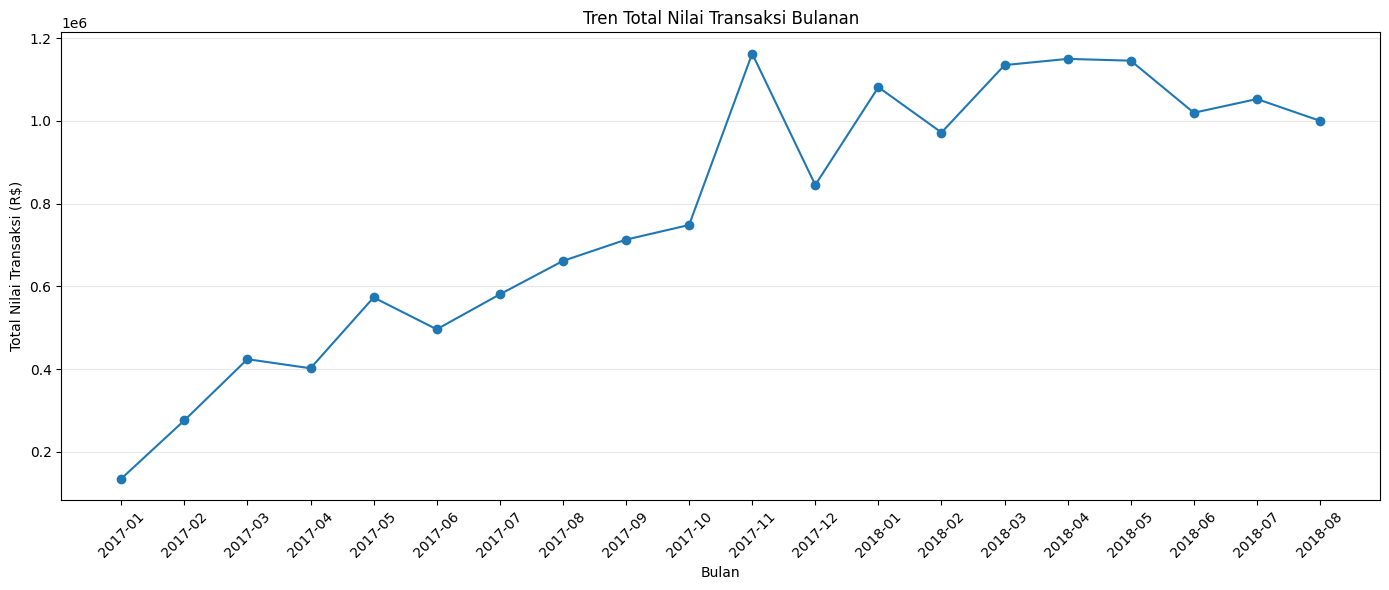

In [90]:
# Visualisasi tren total nilai transaksi bulanan

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transaction['month'],
    monthly_transaction['total_transaction'],
    marker='o'
)

plt.title('Tren Total Nilai Transaksi Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Nilai Transaksi (R$)')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

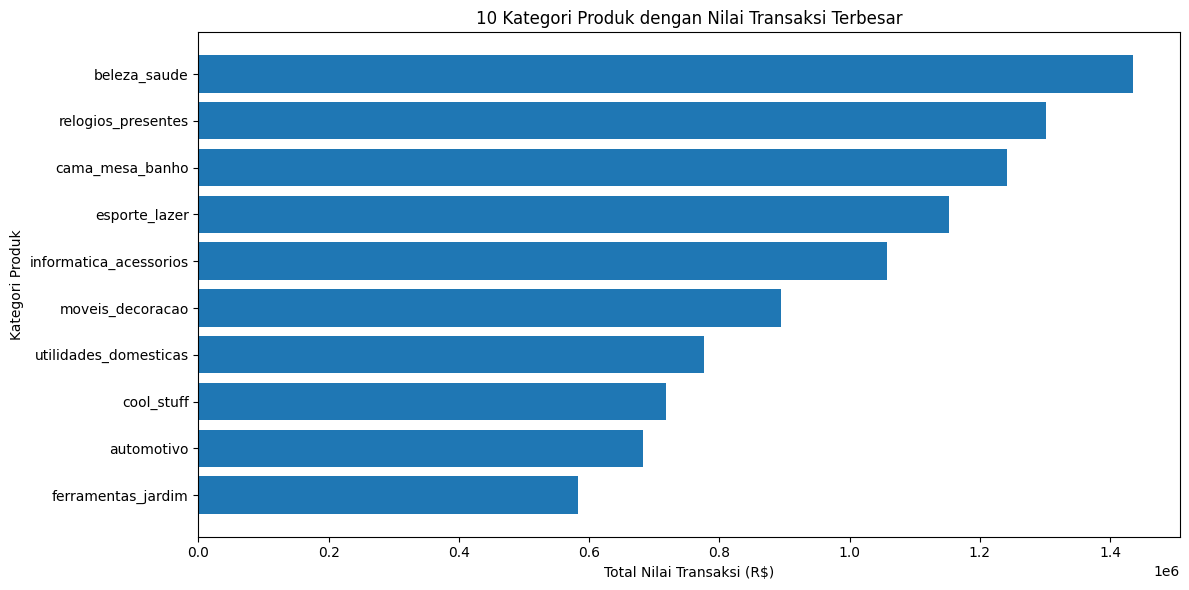

In [92]:
# Mengambil 10 kategori dengan nilai transaksi terbesar

top_10_categories = category_transaction.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_categories['product_category_name'][::-1],
    top_10_categories['total_transaction'][::-1]
)

plt.title('10 Kategori Produk dengan Nilai Transaksi Terbesar')
plt.xlabel('Total Nilai Transaksi (R$)')
plt.ylabel('Kategori Produk')

plt.tight_layout()
plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, total nilai transaksi menunjukkan perubahan dari bulan ke bulan selama periode Januari 2017 hingga Agustus 2018. Secara umum, nilai transaksi mengalami kecenderungan meningkat dibandingkan periode awal, meskipun terdapat beberapa fluktuasi pada bulan tertentu.

Visualisasi kategori produk menunjukkan bahwa kontribusi nilai transaksi tidak tersebar secara merata pada seluruh kategori. Beberapa kategori memiliki nilai transaksi yang jauh lebih tinggi dibandingkan kategori lainnya. Kategori dengan nilai transaksi terbesar menjadi kategori yang paling berkontribusi terhadap total nilai transaksi selama periode analisis.

### Pertanyaan 2: 

Bagaimana pengaruh ketepatan waktu pengiriman terhadap skor ulasan pelanggan pada transaksi yang terjadi selama periode Januari 2017 hingga Agustus 2018?

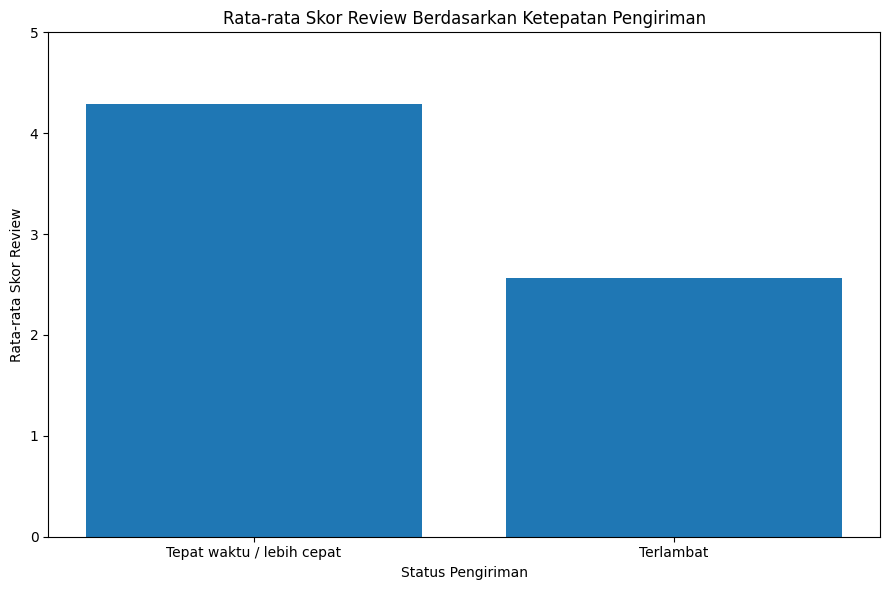

In [93]:
# Visualisasi rata-rata skor review berdasarkan ketepatan pengiriman

plt.figure(figsize=(9, 6))

plt.bar(
    delivery_review['delivery_status'],
    delivery_review['average_review']
)

plt.title('Rata-rata Skor Review Berdasarkan Ketepatan Pengiriman')
plt.xlabel('Status Pengiriman')
plt.ylabel('Rata-rata Skor Review')

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

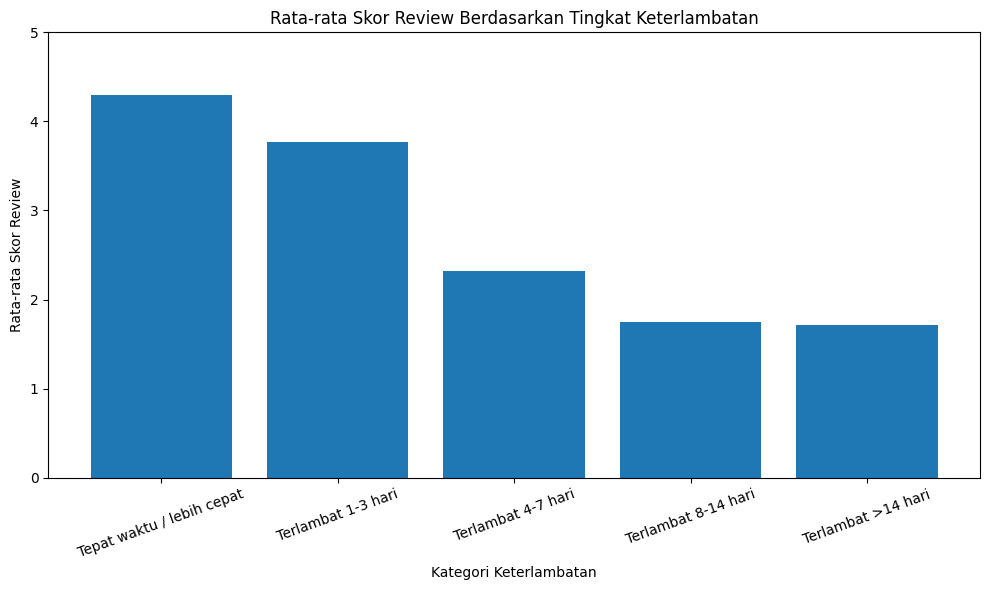

In [94]:
plt.figure(figsize=(10, 6))

plt.bar(
    delay_category_review['delay_category'],
    delay_category_review['average_review']
)

plt.title('Rata-rata Skor Review Berdasarkan Tingkat Keterlambatan')
plt.xlabel('Kategori Keterlambatan')
plt.ylabel('Rata-rata Skor Review')

plt.ylim(0, 5)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, pelanggan yang menerima pesanan tepat waktu atau lebih cepat memberikan rata-rata skor ulasan sebesar 4,29. Sementara itu, pesanan yang terlambat memiliki rata-rata skor ulasan sebesar 2,57.

Ketika keterlambatan dikelompokkan berdasarkan jumlah hari, terlihat pola penurunan skor ulasan seiring bertambahnya durasi keterlambatan. Pesanan yang tepat waktu atau lebih cepat memperoleh rata-rata skor 4,29, sedangkan keterlambatan 1–3 hari memiliki rata-rata skor 3,77. Rata-rata skor kemudian turun menjadi 2,32 pada keterlambatan 4–7 hari dan 1,75 pada keterlambatan 8–14 hari.

Hal ini menunjukkan adanya hubungan yang kuat antara ketepatan waktu pengiriman dengan kepuasan pelanggan yang tercermin melalui skor ulasan. Semakin lama keterlambatan pengiriman, semakin rendah rata-rata skor ulasan yang diberikan pelanggan.

## Analisis Lanjutan (Opsional)

In [96]:
# Menggabungkan data orders dan order items
rfm_df = pd.merge(
    orders_df,
    orders_items_df,
    on='order_id',
    how='inner'
)

# Menggunakan data transaksi pada periode analisis
rfm_df = rfm_df[
    (rfm_df['order_purchase_timestamp'] >= '2017-01-01') &
    (rfm_df['order_purchase_timestamp'] < '2018-09-01')
].copy()

# Menghitung nilai transaksi
rfm_df['total_transaction'] = (
    rfm_df['price'] + rfm_df['freight_value']
)

rfm_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_transaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [97]:
# Menentukan tanggal acuan untuk menghitung Recency
reference_date = pd.Timestamp('2018-09-01')

reference_date

Timestamp('2018-09-01 00:00:00')

In [98]:
rfm = rfm_df.groupby('customer_id').agg(
    Recency=(
        'order_purchase_timestamp',
        lambda x: (
            reference_date - x.max()
        ).days
    ),
    Frequency=(
        'order_id',
        'nunique'
    ),
    Monetary=(
        'total_transaction',
        'sum'
    )
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,290,1,114.74
1,000161a058600d5901f007fab4c27140,411,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,549,1,195.42
3,0002414f95344307404f0ace7a26f1d5,380,1,179.35
4,000379cdec625522490c315e70c7a9fb,151,1,107.01


In [99]:
# Membuat skor RFM
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
).astype(int)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,00012a2ce6f8dcda20d059ce98491703,290,1,114.74,2,1,3
1,000161a058600d5901f007fab4c27140,411,1,67.41,1,1,2
2,0001fd6190edaaf884bcaf3d49edf079,549,1,195.42,1,1,4
3,0002414f95344307404f0ace7a26f1d5,380,1,179.35,2,1,4
4,000379cdec625522490c315e70c7a9fb,151,1,107.01,4,1,3


In [100]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,290,1,114.74,2,1,3,213
1,000161a058600d5901f007fab4c27140,411,1,67.41,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,549,1,195.42,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,380,1,179.35,2,1,4,214
4,000379cdec625522490c315e70c7a9fb,151,1,107.01,4,1,3,413


In [101]:
def rfm_segment(row):

    if (
        row['R_score'] >= 4 and
        row['F_score'] >= 4 and
        row['M_score'] >= 4
    ):
        return 'Best Customers'

    elif (
        row['F_score'] >= 4 and
        row['M_score'] >= 3
    ):
        return 'Loyal Customers'

    elif (
        row['R_score'] >= 4 and
        row['F_score'] <= 3
    ):
        return 'Potential Customers'

    elif row['R_score'] <= 2:
        return 'At Risk / Lost Customers'

    else:
        return 'Regular Customers'


rfm['customer_segment'] = rfm.apply(
    rfm_segment,
    axis=1
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,290,1,114.74,2,1,3,213,At Risk / Lost Customers
1,000161a058600d5901f007fab4c27140,411,1,67.41,1,1,2,112,At Risk / Lost Customers
2,0001fd6190edaaf884bcaf3d49edf079,549,1,195.42,1,1,4,114,At Risk / Lost Customers
3,0002414f95344307404f0ace7a26f1d5,380,1,179.35,2,1,4,214,At Risk / Lost Customers
4,000379cdec625522490c315e70c7a9fb,151,1,107.01,4,1,3,413,Potential Customers


In [102]:
segment_summary = (
    rfm['customer_segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    'customer_segment',
    'customer_count'
]

segment_summary

,customer_segment,customer_count
0,At Risk / Lost Customers,30036
1,Potential Customers,23856
2,Regular Customers,20822
3,Loyal Customers,17145
4,Best Customers,6494


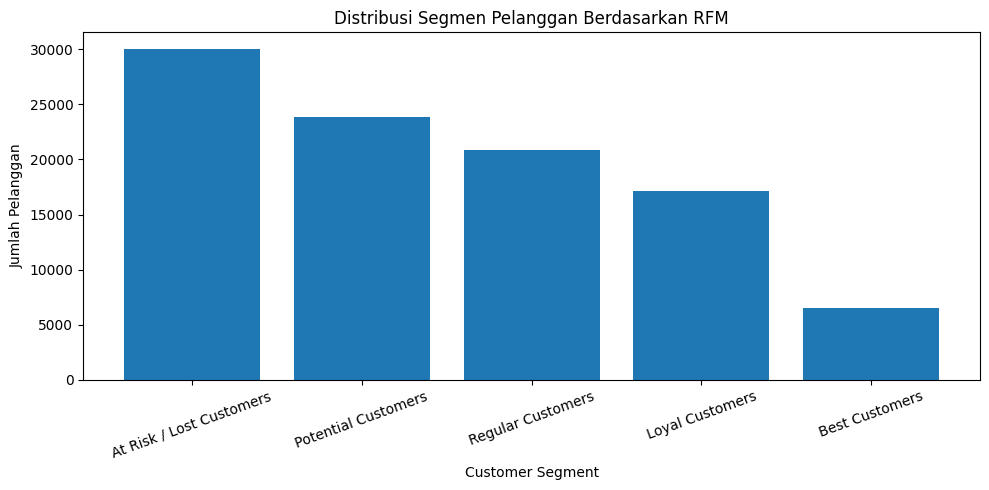

In [103]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary['customer_segment'],
    segment_summary['customer_count']
)

plt.xlabel('Customer Segment')
plt.ylabel('Jumlah Pelanggan')
plt.title('Distribusi Segmen Pelanggan Berdasarkan RFM')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [104]:
rfm_summary = (
    rfm
    .groupby('customer_segment')
    .agg(
        customer_count=('customer_id', 'count'),
        avg_recency=('Recency', 'mean'),
        avg_frequency=('Frequency', 'mean'),
        avg_monetary=('Monetary', 'mean')
    )
    .sort_values(
        'avg_monetary',
        ascending=False
    )
)

rfm_summary

,customer_count,avg_recency,avg_frequency,avg_monetary
customer_segment,,,,
Best Customers,6494,95.226363,1.0,296.885462
Loyal Customers,17145,291.731875,1.0,206.461038
Potential Customers,23856,94.712441,1.0,163.923971
At Risk / Lost Customers,30036,398.147756,1.0,138.627828
Regular Customers,20822,186.969792,1.0,107.773470


**Insight:** (Opsional)
- Segmen Best Customers terdiri dari X pelanggan dengan rata-rata frekuensi transaksi sebesar X kali dan rata-rata pengeluaran sebesar R$ X.
- Segmen At Risk / Lost memiliki rata-rata Recency sebesar X hari, menunjukkan bahwa kelompok tersebut sudah cukup lama tidak melakukan transaksi.
- Hasil RFM menunjukkan bahwa pelanggan dengan frekuensi dan nilai transaksi tinggi perlu dipertahankan melalui program loyalitas, sedangkan pelanggan yang sudah lama tidak bertransaksi dapat ditargetkan dengan kampanye reaktivasi.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Total nilai transaksi selama periode Januari 2017 hingga Agustus 2018 menunjukkan tren yang cenderung meningkat meskipun terdapat beberapa fluktuasi antarbulan. Berdasarkan kategori produk, **beleza_saude** menjadi kategori dengan kontribusi nilai transaksi terbesar, yaitu sebesar **R$ 1.435.611,23** atau sekitar **9,22%** dari total nilai transaksi. Kategori berikutnya adalah **relogios_presentes** sebesar **R$ 1.302.073,57** (8,36%) dan **cama_mesa_banho** sebesar **R$ 1.241.075,14** (7,97%).

- **Conclusion pertanyaan 2:** Terdapat hubungan yang jelas antara ketepatan waktu pengiriman dan skor ulasan pelanggan. Pesanan yang sampai tepat waktu atau lebih cepat memiliki rata-rata skor ulasan sebesar **4,29**, sedangkan pesanan yang terlambat memiliki rata-rata skor **2,57**. Selain itu, semakin lama keterlambatan pengiriman, semakin rendah rata-rata skor ulasan pelanggan. Rata-rata skor turun dari **4,29** untuk pesanan tepat waktu atau lebih cepat menjadi **3,77** pada keterlambatan 1–3 hari, **2,32** pada keterlambatan 4–7 hari, **1,75** pada keterlambatan 8–14 hari, dan **1,71** pada keterlambatan lebih dari 14 hari.



**Rekomendasi Action Item:**

- Memprioritaskan kategori **beleza_saude**, **relogios_presentes**, dan **cama_mesa_banho** dalam strategi penjualan karena ketiga kategori tersebut memberikan kontribusi nilai transaksi terbesar.
- Menjaga ketersediaan stok dan meningkatkan strategi promosi pada kategori dengan kontribusi transaksi tinggi untuk mempertahankan performa penjualan.
- Meningkatkan pemantauan proses pengiriman agar pesanan dapat sampai sesuai atau lebih cepat dari estimasi yang diberikan kepada pelanggan.
- Melakukan evaluasi terhadap proses logistik pada pesanan yang mengalami keterlambatan, terutama keterlambatan lebih dari 7 hari, karena kelompok tersebut memiliki rata-rata skor ulasan yang jauh lebih rendah.
- Melakukan monitoring secara berkala terhadap persentase pesanan terlambat dan rata-rata skor ulasan sebagai indikator untuk mengevaluasi kualitas layanan pengiriman.